# Demo Notebook for Molten Salt Analyzer

This notebook demonstrates how to use the `MoltenSaltAnalyzer` class to analyze the results of a Molten Salt Simulator simulation (see `simulator.ipynb`). The results are printed to the console and displayed in the notebook as plots.

## Initialization

The analyzer is initialized with the path to the trajectory file. The trajectory file can be an NPT or NVT trajectory or both. If both are provided, the analyzer will select the more suitable trajectory for the specific analysis. For the plotting, the module `myplots` module version `0.1.0` was employed (you can install it from pip).

In [1]:
import os

from ase import units
from ase.data import chemical_symbols
import numpy as np

import moltensaltcalc as msc
import myplots as p

# Initialize the plotting settings
p.use_style()

# Set a random seed for reproducibility
np.random.seed(42)

DATA_DIR = os.path.join("demo_simulation_results", "GRACE_1L_NaCl_super_short")

# Assumes the NPT and NVT trajectories have already been generated with the simulator (generate with simulator.py)
npt_dir = os.path.join(DATA_DIR, "NPT")
nvt_dir = os.path.join(DATA_DIR, "NVT")
# We use the same temperatures for both ensembles
temperatures = [1100, 1150, 1200]
npt_trajs = [os.path.join(npt_dir, f"npt_NaCl_{T}K.traj") for T in temperatures]
nvt_trajs = [os.path.join(nvt_dir, f"nvt_NaCl_{T}K.traj") for T in temperatures]

analyzer = msc.MoltenSaltAnalyzer(
    npt_trajs, nvt_trajs, temperatures_npt=temperatures, temperatures_nvt=temperatures
)

# Typically 0.1, but since the example trajectories contain only 10 frames, 0.6 is used
eq_frac = 0.6

## Density vs. Time and Equilibrium Density

The evolution of the density during the simulation can be computed from the NPT trajectory file using the `compute_density_vs_time` method. This method returns the densities in g/cm³ and the corresponding simulation times in fs. The equilibrium density can be determined from the mean density of the last x% of the simulation time using the `compute_eq_density` method.

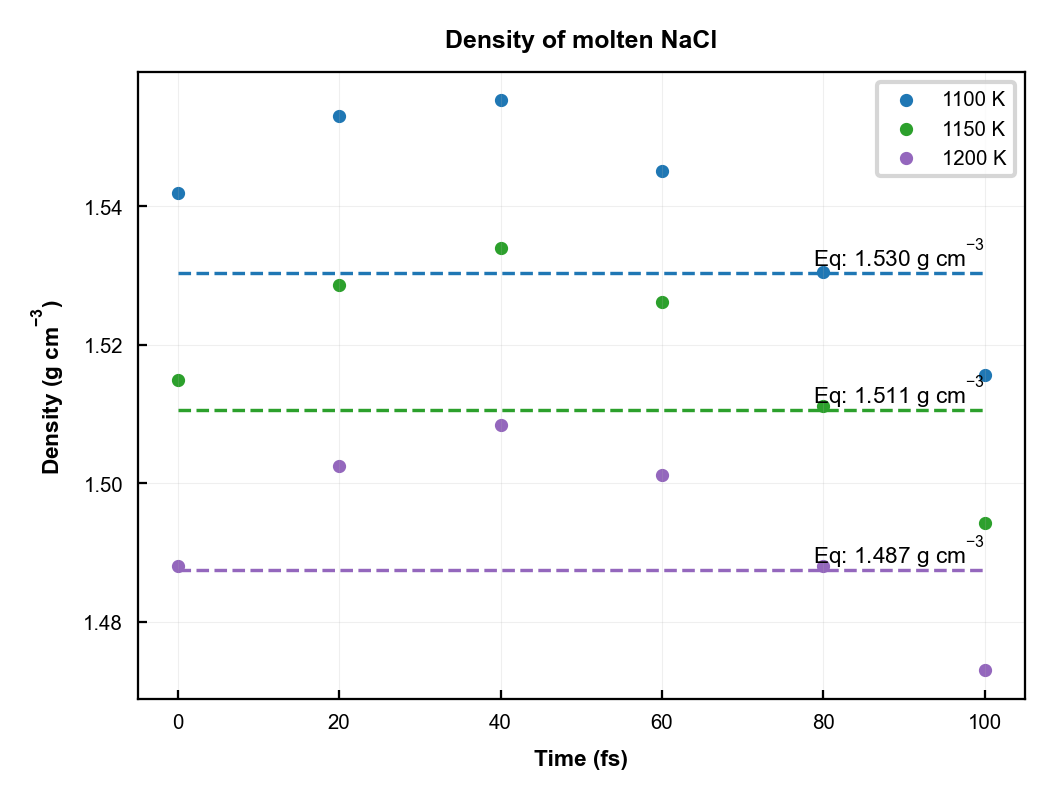

In [2]:
fig, ax = p.new()
for T in temperatures:
    densities, times = analyzer.compute_density_vs_time(T)
    eq_density = analyzer.compute_eq_density(T, eq_frac)
    p.scatter(ax, times, densities, label=f"{T} K")
    p.line(ax, [times[0], times[-1]], [eq_density, eq_density], ls="--")
    ax.text(
        times[-1],
        eq_density,
        f"Eq: {eq_density:.3f} g cm$^{{-3}}$",
        ha="right",
        va="bottom",
    )

p.label(ax, "Time (fs)", "Density (g cm$^{{-3}}$)", "Density of molten NaCl")
p.legend(ax)

## Thermal Expansion

The thermal expansion coefficient is computed from linear fit of the equilibrium volumes (last `eq_fraction` time fraction) normalized by the mean volume. The fit is performed for each temperature in the initialized analyzer. The method `compute_thermal_expansion` returns results as a dictionary with the following keys:

- "temperatures": List of temperatures in K
- "eq_vols": Equilibrium volumes in Å³ for each temperature
- "eq_vols_norm": Equilibrium volumes normalized to the mean volume
- "fit": Fit parameters
- "fit_line": Fit line
- "thermal_expansion": Thermal expansion coefficient in 1/K

Thermal expansion:  β = 2.846825e-04 K⁻¹


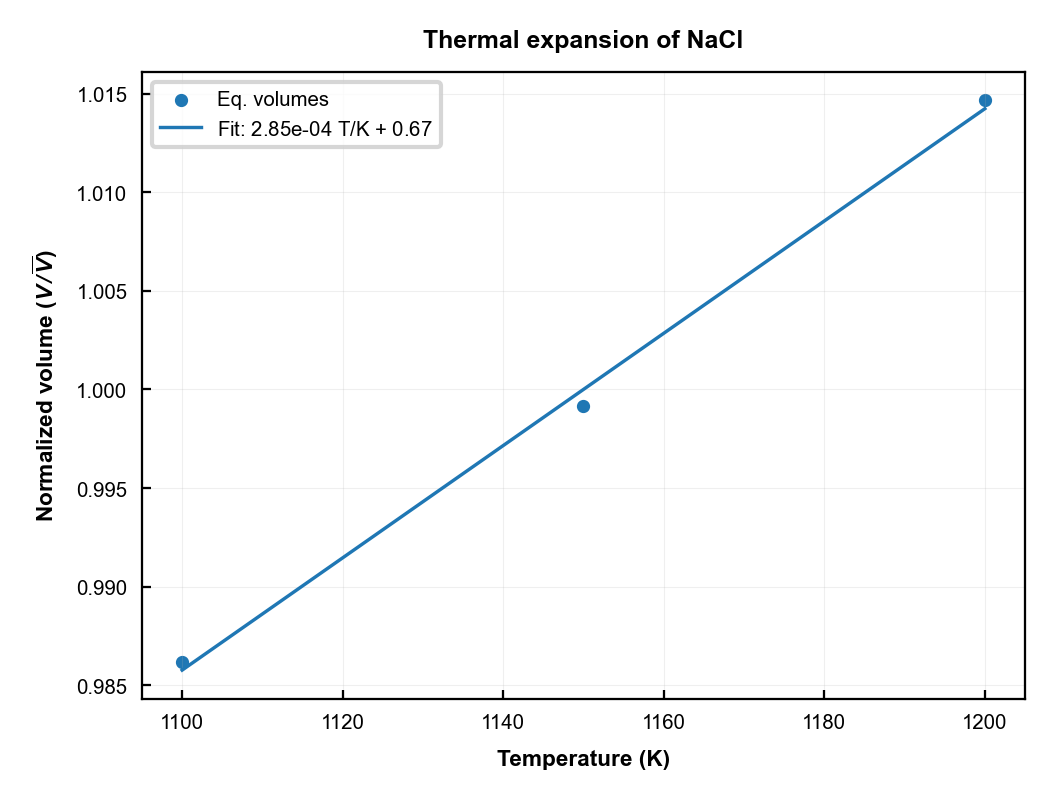

In [3]:
thm_exp_results = analyzer.compute_thermal_expansion(eq_frac)
print(f"Thermal expansion:  β = {thm_exp_results['thermal_expansion']:.6e} K⁻¹")

fig, ax = p.new()
p.scatter(
    ax,
    thm_exp_results["temperatures"],
    thm_exp_results["eq_vols_norm"],
    label="Eq. volumes",
)
p.line(
    ax,
    thm_exp_results["temperatures"],
    thm_exp_results["fit_line"],
    label=f"Fit: {thm_exp_results['fit'][0]:.2e} $T$/K + {thm_exp_results['fit'][1]:.2f}",
)
p.label(
    ax,
    "Temperature (K)",
    f"Normalized volume ({p.bm('V \\, / \\, \\overline{{V}}')})",
    "Thermal expansion of NaCl",
)
p.legend(ax)

## Specific Heat Capacity

The specific heat capacity is estimated from the NVT trajectory by the approximation:

$$ C \approx \frac{\hat U}{k_\text{B} T^2 m_\text{tot}} $$

where $\hat U$ is the estimated variance of the total energy, $k_\text{B}$ is Boltzmann's constant, $T$ is the temperature in K, and $m_\text{tot}$ is the total mass of the system. The method `compute_heat_capacity` returns the heat capacity in J/g/K.

In [4]:
for T in temperatures:
    heat_cap = analyzer.compute_heat_capacity(T, eq_frac)
    print(f"Heat capacity at {T} K: C = {heat_cap:.6e} J/g/K")

Heat capacity at 1100 K: C = 7.355534e-04 J/g/K
Heat capacity at 1150 K: C = 4.915646e-05 J/g/K
Heat capacity at 1200 K: C = 4.606643e-04 J/g/K


## Diffusion Coefficients and Arrhenius Fit

The diffusion coefficient is computed from the mean square displacement (msd) of the atoms. For efficiency, the msd is by default computed without variation of time origins. `compute_diffusion_coefficient` returns the diffusion coefficient in Å²/fs.

If the diffusion coefficients are computed at different temperatures, the Arrhenius fit can be performed with `fit_arrhenius`, which returns a dictionary containing:

- `Ea`: Activation energy in J/mol
- `D0`: Exponential prefactor of the Arrhenius law in Å²/fs
- `slope`: Slope of the Arrhenius law
- `intercept`: Intercept of the Arrhenius law

Diffusion coefficient at 1100 K: D = 1.006781e-03 Å²/fs
Diffusion coefficient at 1150 K: D = 8.790549e-04 Å²/fs
Diffusion coefficient at 1200 K: D = 1.209916e-03 Å²/fs
Arrhenius parameters for the self-diffusion of NaCl: Ea = 1.943528e+04 J/mol, D0 = 7.830288e-03 Å²/fs


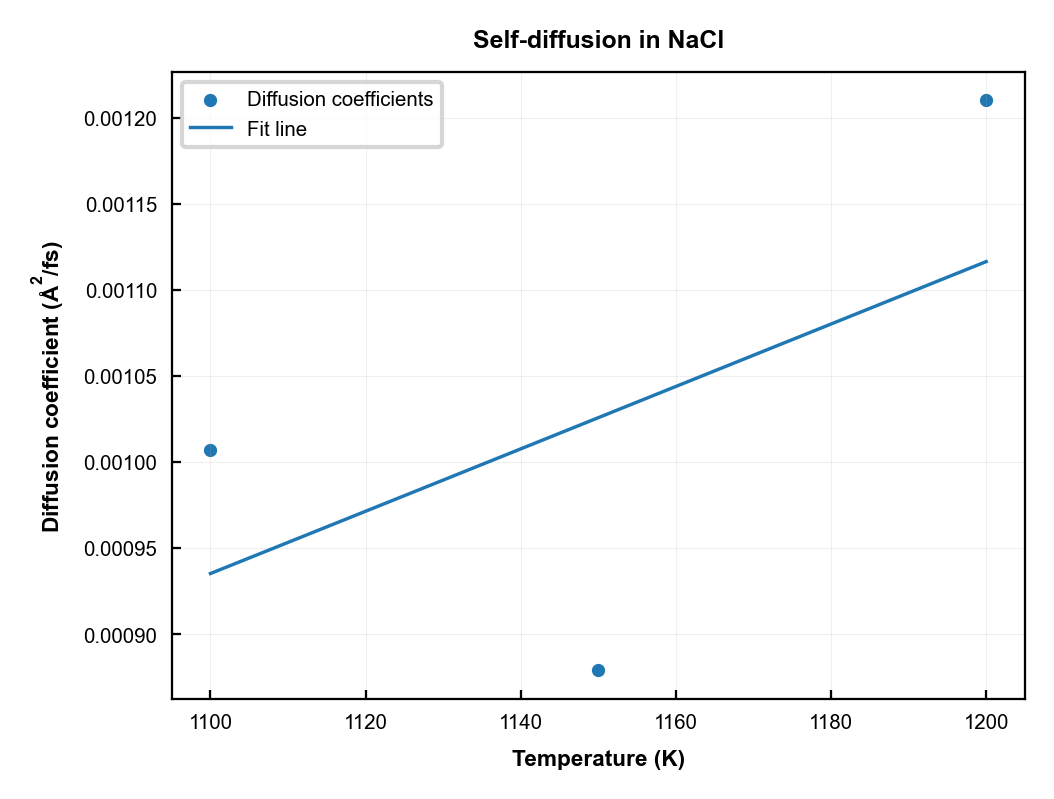

In [5]:
diffusion_coeffs = []
for T in temperatures:
    # Set up the analyzer for each of the NVT trajectories to get the diffusion coefficient there
    diff_coeff = analyzer.compute_diffusion_coefficient(T)
    print(f"Diffusion coefficient at {T} K: D = {diff_coeff:.6e} Å²/fs")
    diffusion_coeffs.append(diff_coeff)
# Get the activation energy
diffusion_results = analyzer.fit_arrhenius(temperatures, diffusion_coeffs)
print(
    f"Arrhenius parameters for the self-diffusion of NaCl: Ea = {diffusion_results['Ea']:.6e} J/mol, D0 = {diffusion_results['D0']:.6e} Å²/fs"
)

fig, ax = p.new()
p.scatter(ax, temperatures, diffusion_coeffs, label="Diffusion coefficients")
fit_T = np.linspace(min(temperatures), max(temperatures), 100)
fit_D = diffusion_results["D0"] * np.exp(diffusion_results["slope"] / fit_T)
p.line(ax, fit_T, fit_D, label="Fit line")
p.label(
    ax,
    "Temperature (K)",
    "Diffusion coefficient ($\\AA^2 / fs$)",
    "Self-diffusion in NaCl",
)
p.legend(ax)

## Radial Distribution Functions

The radial distribution functions (RDFs) are computed for each pair of atoms in the system by calling the `get_rdf` function from the `ase.geometry.rdf` module and averaging the results over the last `max_num_frames` frames. The function `compute_rdf` returns a dictionary with the distances and the average RDF for each (selected) pair. The distances are in Å and the average RDF is unitless (normalized).

Radial distribution function for (11, 11) at 1100 K: g(r) = [0.   0.   0.   0.   0.01 0.5  2.02 1.92 0.6  0.59]... at distances [0.3 0.9 1.5 2.1 2.7 3.3 3.9 4.5 5.1 5.7]... Å
Radial distribution function for (11, 17) at 1100 K: g(r) = [0.   0.   0.   0.31 3.17 1.2  0.47 0.65 0.97 1.  ]... at distances [0.3 0.9 1.5 2.1 2.7 3.3 3.9 4.5 5.1 5.7]... Å
Radial distribution function for (11, 11) at 1150 K: g(r) = [0.   0.   0.   0.   0.03 0.55 2.17 1.75 0.72 0.54]... at distances [0.3 0.9 1.5 2.1 2.7 3.3 3.9 4.5 5.1 5.7]... Å
Radial distribution function for (11, 17) at 1150 K: g(r) = [0.   0.   0.   0.33 3.33 1.04 0.57 0.66 0.93 1.07]... at distances [0.3 0.9 1.5 2.1 2.7 3.3 3.9 4.5 5.1 5.7]... Å
Radial distribution function for (11, 11) at 1200 K: g(r) = [0.   0.   0.   0.   0.03 0.57 1.86 1.82 0.78 0.61]... at distances [0.3 0.9 1.5 2.1 2.7 3.3 3.9 4.5 5.1 5.7]... Å
Radial distribution function for (11, 17) at 1200 K: g(r) = [0.   0.   0.   0.33 3.07 1.21 0.58 0.66 0.9  1.04]... at distanc

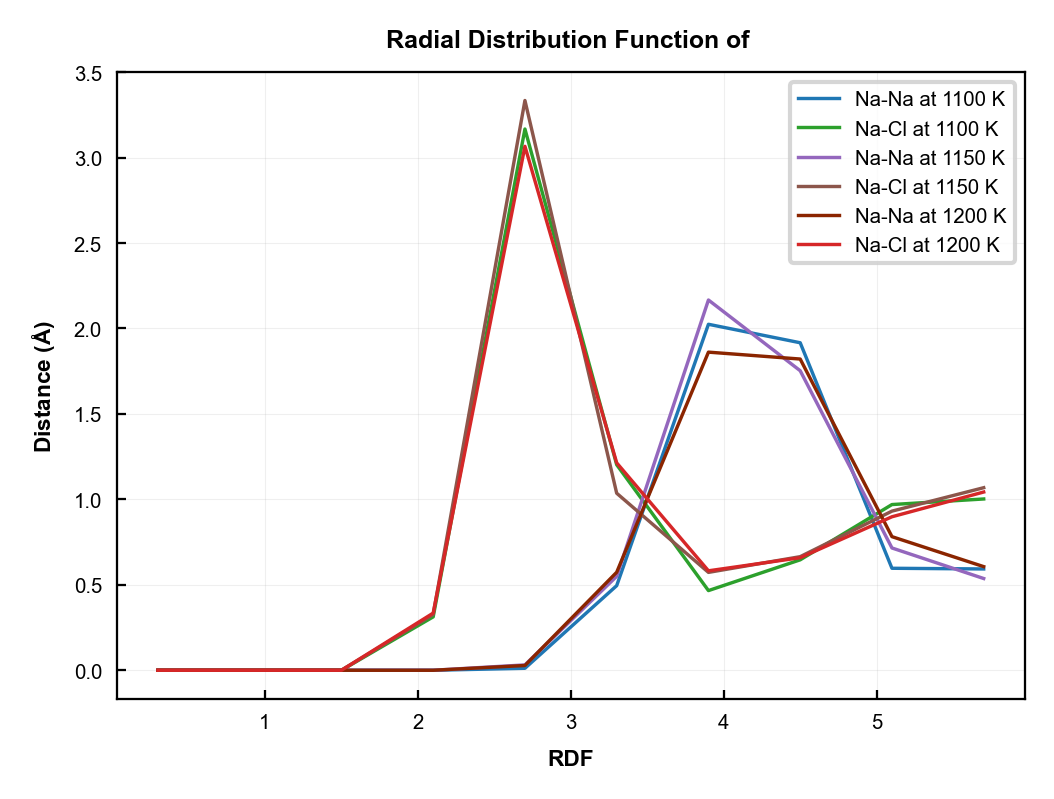

In [6]:
fig, ax = p.new()
selected_pairs = [(11, 11), (11, 17)]
for T in temperatures:
    rdf_data = analyzer.compute_rdf(
        T=T, max_num_frames=10, pairs=selected_pairs, nbins=10
    )
    for pair in selected_pairs:
        print(
            f"Radial distribution function for {pair} at {T} K: g(r) = {np.round(rdf_data[pair][1], 2)}... at distances {rdf_data[pair][0]}... Å"
        )
        p.line(
            ax,
            rdf_data[pair][0],
            rdf_data[pair][1],
            label=f"{chemical_symbols[pair[0]]}-{chemical_symbols[pair[1]]} at {T} K",
        )
p.label(ax, "RDF", "Distance ($\\AA$)", "Radial Distribution Function of ")
p.legend(ax)

## Viscosity

The viscosity is estimated using the Green-Kubo relation:

$$ \eta = \frac{V}{k_{\text{B}}T} \int_{t_0}^{t_{\text{max}}} \langle \sigma_{\alpha \beta}(0) \sigma_{\alpha \beta}(\tau) \rangle \text{d}\tau $$

where $V$ denotes the system volume, $k_{\text{B}}$ is the Boltzmann constant, $T$ is the temperature, $\sigma_{\alpha \beta}(\tau)$ is the microscopic stress tensor at time $\tau$ in direction $\alpha \beta$, and $\langle \cdot \rangle$ denotes the autocorrelation function over different time origins. The parameter `tmax_fs` determines the maximum correlation time in femtoseconds. The autocorrelation function is computed using FFT.

The function `compute_viscosity` returns the viscosity in Pa s and the autocorrelation function and times, so they can be used to check that `tmax_fs` is sufficiently small to only capture the plateau of the autocorrelation function and not sample the following noise, which leads to a wrong estimation of the viscosity.

Viscosity at 1100 K: η = 1.360223e-05 Pa·s
Viscosity at 1150 K: η = 2.195635e-05 Pa·s
Viscosity at 1200 K: η = 9.732963e-05 Pa·s


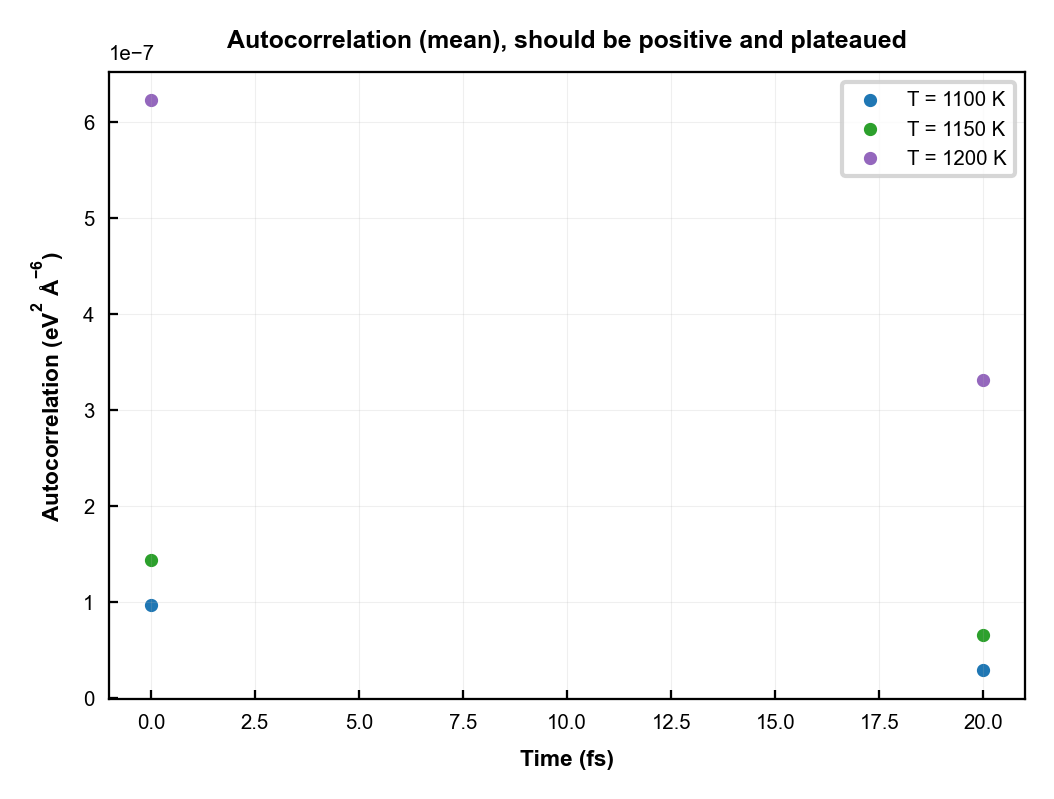

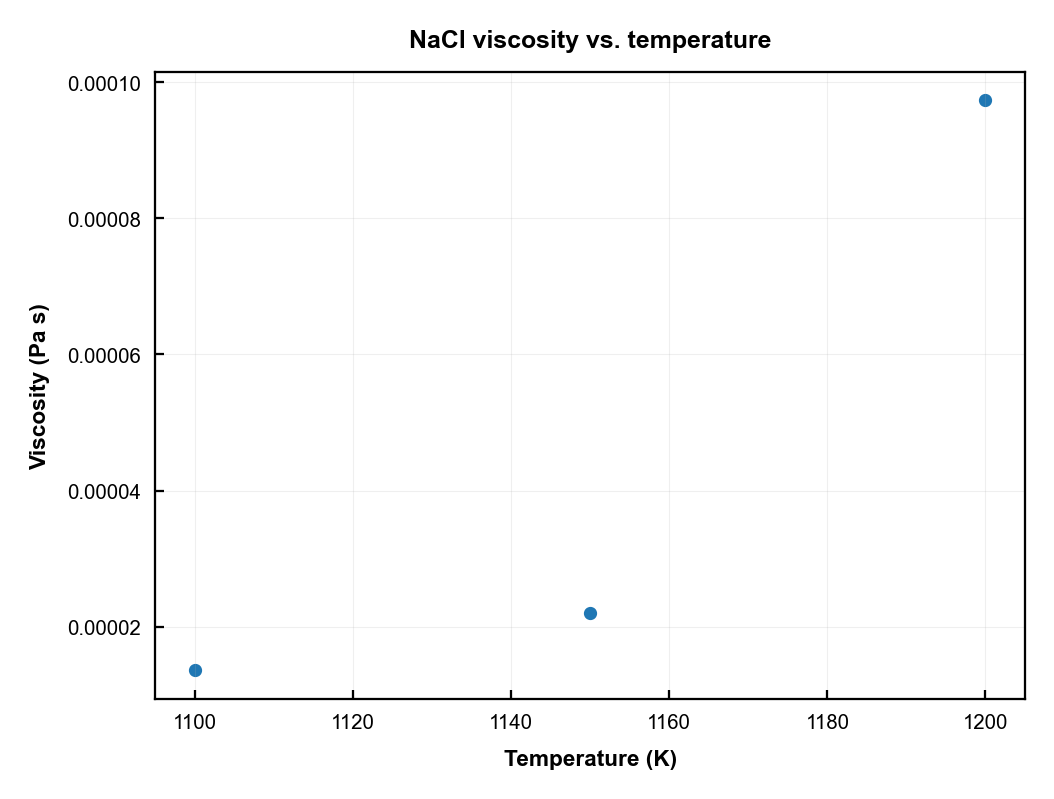

In [7]:
viscosities = []
fig, ax = p.new()
for T in temperatures:
    viscosity, (ac_mean, ac_times) = analyzer.compute_viscosity(T, tmax_fs=25)
    # ac_mean and ac_times can be used to check that the plateau of the autocorrelation function reaches tmax_fs
    p.scatter(ax, ac_times, ac_mean, f"T = {T} K")
    viscosities.append(viscosity)
    print(f"Viscosity at {T} K: η = {viscosity:.6e} Pa·s")

p.label(
    ax,
    "Time (fs)",
    "Autocorrelation (eV$^2$ $\\AA^{-6}$)",
    "Autocorrelation (mean), should be positive and plateaued",
)
p.legend(ax)

fig, ax = p.new()
p.scatter(ax, temperatures, viscosities)
p.label(ax, "Temperature (K)", "Viscosity (Pa s)", "NaCl viscosity vs. temperature")
p.legend(ax)